In [18]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import SimpleRNN
from keras.layers import LSTM
from keras.layers import GRU
from keras.layers import Input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_squared_error

from Unit19.Lecture import patience

In [3]:
dataset = pd.read_csv('airline-passengers.csv')
dataset['Month'] = pd.to_datetime(dataset['Month'])
dataset.set_index(['Month'], inplace=True)

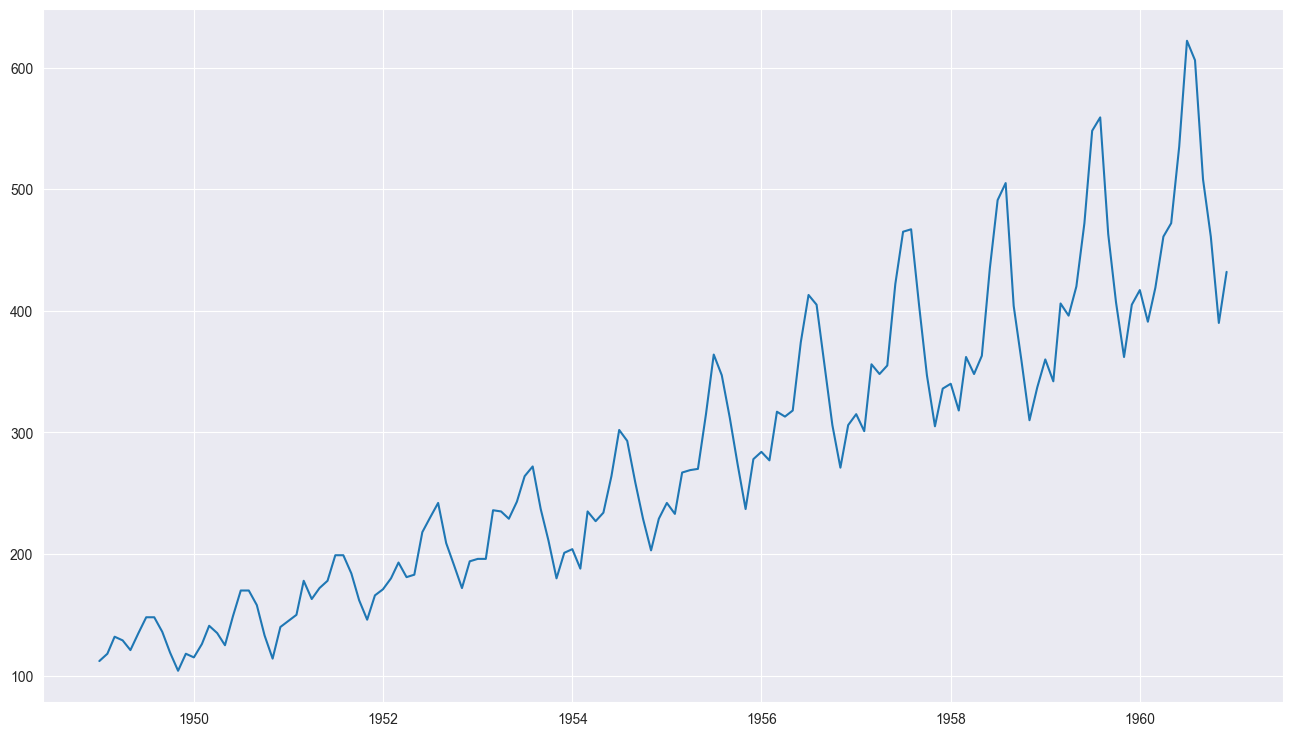

In [4]:
plt.figure(figsize=(16,9))
plt.plot(dataset['Passengers'])
plt.show()

In [5]:
train_size = int(len(dataset) * 0.70)
scaler = MinMaxScaler(feature_range=(0, 1))
look_back = 3
def create_dataset(df, train_size, lback=look_back, scaler_function=scaler):
    test_size = len(df) - train_size
    train, test = df[0:train_size,:].copy(), df[train_size:len(df),:].copy()
    train = scaler_function.fit_transform(train)
    test = scaler_function.transform(test)
    X_train, X_test, y_train, y_test = [], [], [], []

    # Tworzenie zbioru treninowego
    for i in range(len(train)-lback-1):
        a = train[i:(i+lback), 0]
        X_train.append(a)
        y_train.append(train[i + lback, 0])

    # Tworzenie zbioru testowego
    for i in range(len(test)-lback-1):
        a = test[i:(i+lback), 0]
        X_test.append(a)
        y_test.append(test[i + lback, 0])

    X_train, X_test = np.array(X_train), np.array(X_test)
    X_train, X_test = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1])), np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
    y_train, y_test = np.array(y_train), np.array(y_test)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = create_dataset(df=np.array(dataset), train_size=train_size, lback=look_back)

In [6]:
model_rnn = Sequential()
model_rnn.add(SimpleRNN(5, input_shape=(1, look_back)))
model_rnn.add(Dense(1))
model_rnn.compile(loss='mean_squared_error', optimizer='adam')
model_rnn.fit(X_train, y_train, epochs=200, batch_size=1, verbose=1)

D:\ML_AI\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 903us/step - loss: 0.0124
Epoch 2/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - loss: 0.0108
Epoch 3/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step - loss: 0.0102
Epoch 4/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - loss: 0.0098
Epoch 5/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step - loss: 0.0093
Epoch 6/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - loss: 0.0093
Epoch 7/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - loss: 0.0087
Epoch 8/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - loss: 0.0088
Epoch 9/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step - loss: 0.0083   
Epoch 10/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - loss: 0.0082
Epoch 11/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - loss: 0.0078   
Epoch 12/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 600us/step - loss: 0.0079   
Epoch 13/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step - loss: 0.0074
Epoch 14/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step - loss: 0.0076
Epoch 15/200
96/96 ━━━━━━━━━━━━━━━

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


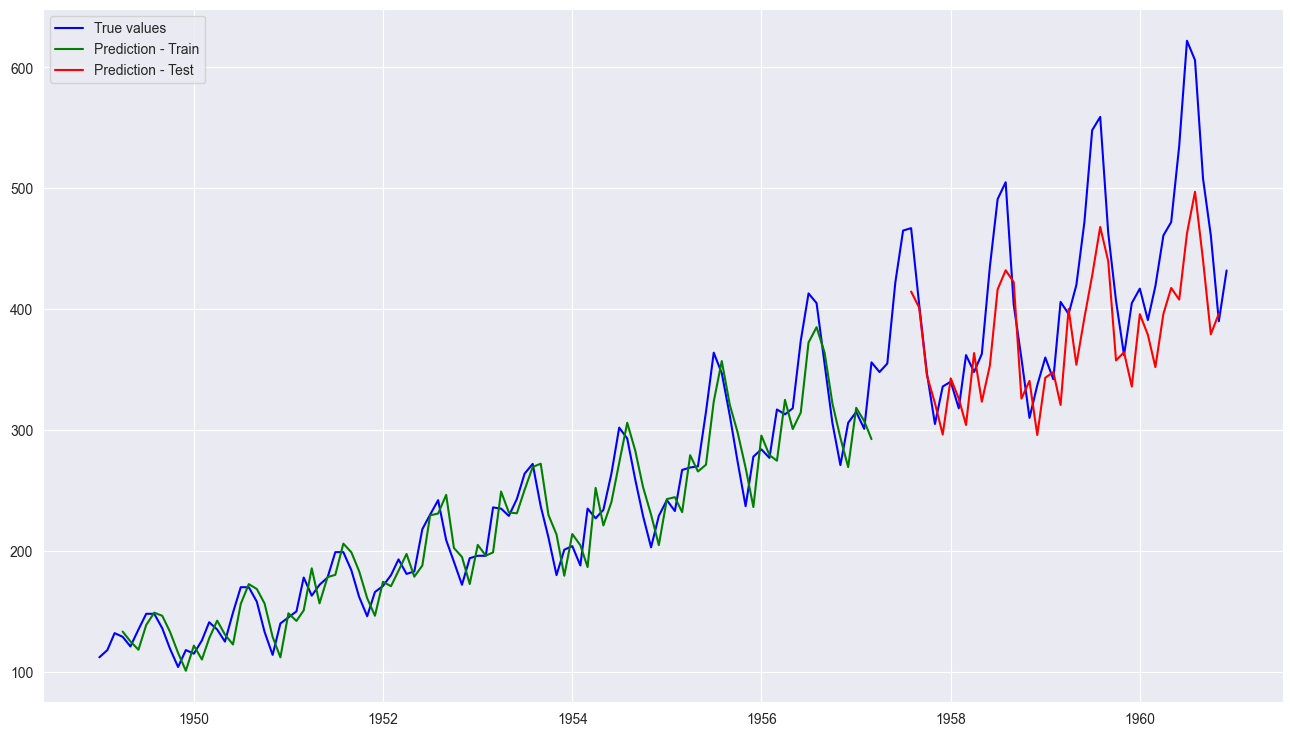


RMSE TEST: 62.667911165474074


In [7]:
def backtests(model, lback=look_back):

    # predykcja - train
    prediction_train = scaler.inverse_transform(model.predict(X_train))
    prediction_train = pd.Series(prediction_train.flatten(),
                                index=dataset.index[lback:len(prediction_train)+lback])

    # predykcja - test
    prediction_test = scaler.inverse_transform(model.predict(X_test))
    prediction_test = pd.Series(prediction_test.flatten(),
                                index=dataset.index[len(prediction_train)+(2*lback)+1:len(dataset)-1])

    # wizualizacja prognozy
    plt.figure(figsize=(16,9))
    plt.plot(dataset['Passengers'], color='blue', label='True values')
    plt.plot(prediction_train, color='green', label='Prediction - Train')
    plt.plot(prediction_test, color='red', label='Prediction - Test')
    plt.legend(loc='upper left')
    plt.show()

    # obliczenie RMSE
    rmse = mean_squared_error(dataset.loc[prediction_test.index, :], prediction_test) ** 0.5
    print(f'\nRMSE TEST: {rmse}')

backtests(model_rnn)

D:\ML_AI\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 700us/step - loss: 0.1561
Epoch 2/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - loss: 0.0645
Epoch 3/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - loss: 0.0345
Epoch 4/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step - loss: 0.0268
Epoch 5/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step - loss: 0.0239
Epoch 6/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step - loss: 0.0205
Epoch 7/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 644us/step - loss: 0.0181
Epoch 8/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - loss: 0.0165
Epoch 9/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step - loss: 0.0150
Epoch 10/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step - loss: 0.0140
Epoch 11/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step - loss: 0.0131
Epoch 12/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step - loss: 0.0126
Epoch 13/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - loss: 0.0122
Epoch 14/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - loss: 0.0120
Epoch 15/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 

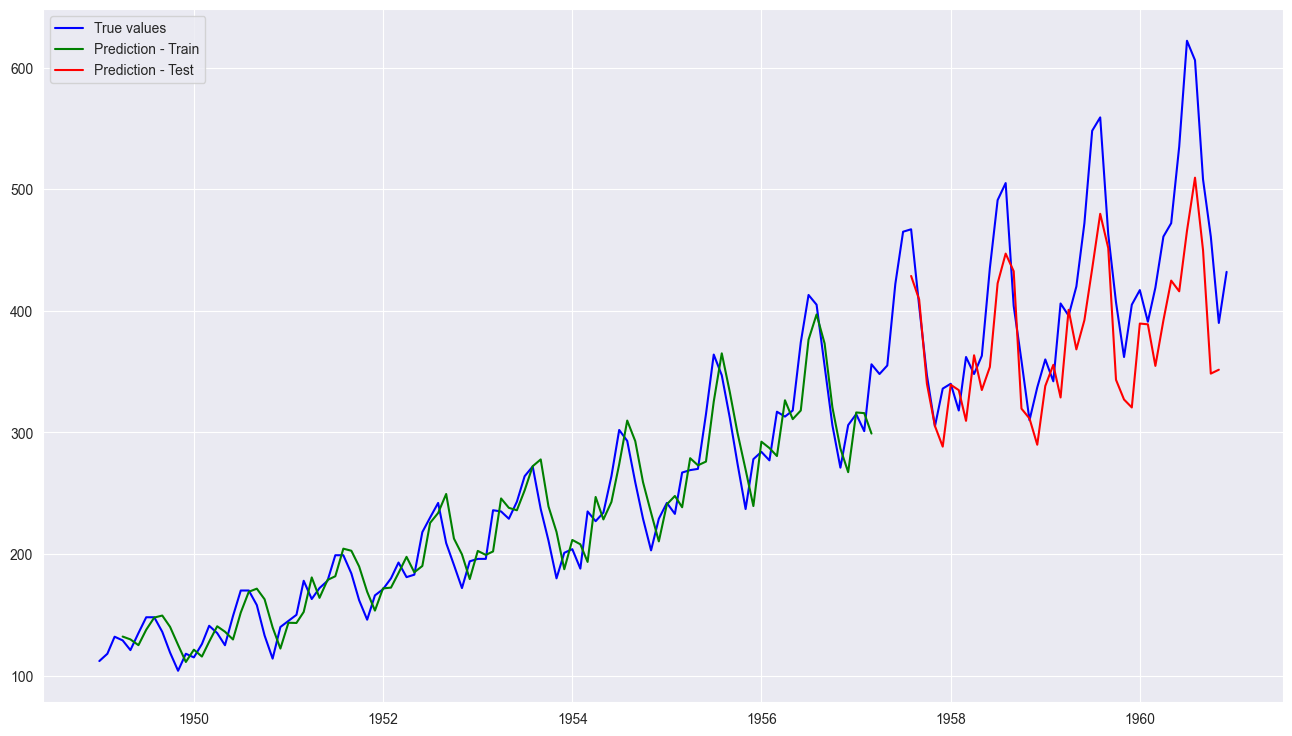


RMSE TEST: 61.61771595833357


In [8]:
model_lstm = Sequential()
model_lstm.add(LSTM(5, input_shape=(1, look_back)))
model_lstm.add(Dense(1))
model_lstm.compile(loss='mean_squared_error', optimizer='adam')
model_lstm.fit(X_train, y_train, epochs=200, batch_size=1, verbose=1)
backtests(model_lstm)

Epoch 1/200


D:\ML_AI\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 648us/step - loss: 0.0477
Epoch 2/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step - loss: 0.0183
Epoch 3/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step - loss: 0.0140
Epoch 4/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - loss: 0.0115
Epoch 5/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step - loss: 0.0099
Epoch 6/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - loss: 0.0092
Epoch 7/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step - loss: 0.0084
Epoch 8/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step - loss: 0.0083
Epoch 9/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step - loss: 0.0081
Epoch 10/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - loss: 0.0078
Epoch 11/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step - loss: 0.0079
Epoch 12/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step - loss: 0.0075
Epoch 13/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 655us/step - loss: 0.0080
Epoch 14/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step - loss: 0.0076
Epoch 15/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step -

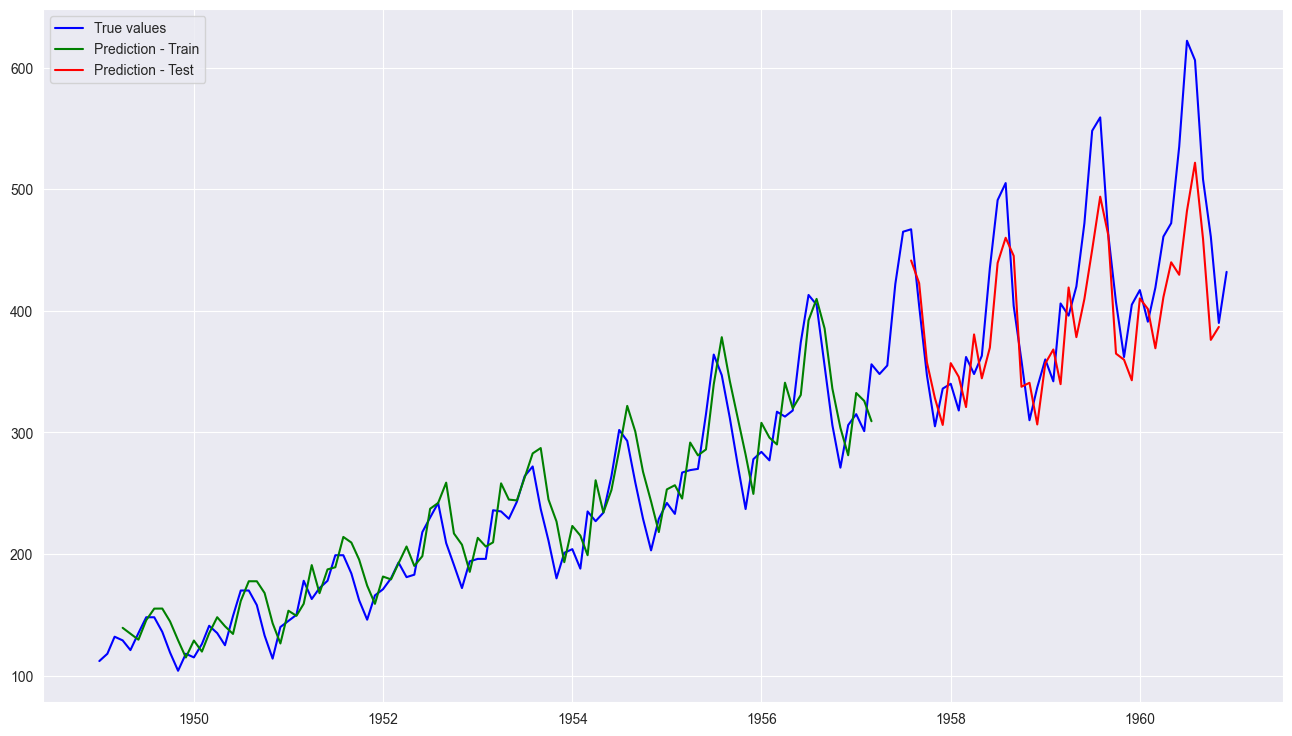


RMSE TEST: 50.972337588330696


In [9]:
model_gru = Sequential()
model_gru.add(GRU(5, input_shape=(1, look_back)))
model_gru.add(Dense(1))
model_gru.compile(loss='mean_squared_error', optimizer='adam')
model_gru.fit(X_train, y_train, epochs=200, batch_size=1, verbose=1)
backtests(model_gru)

# Excercise

In [10]:
dataset = pd.read_csv('airline-passengers.csv')
dataset['Month'] = pd.to_datetime(dataset['Month'])
dataset.set_index('Month', inplace=True)

values = dataset[['Passengers']].values
train_size = int(len(values) * 0.70)

In [12]:
def create_datasets(values, train_size, look_back, val_ratio=0.2):
    scaler = MinMaxScaler(feature_range=(0, 1))

    train_raw = values[:train_size]
    test_raw = values[train_size - look_back:]

    train_scaled = scaler.fit_transform(train_raw)
    test_scaled = scaler.transform(test_raw)

    def to_supervised(data):
        X, y = [], []
        for i in range(len(data) - look_back):
            X.append(data[i:i+look_back, 0])
            y.append(data[i+look_back, 0])
        return np.array(X), np.array(y)

    X_train_full, y_train_full = to_supervised(train_scaled)

    val_size = int(len(X_train_full) * val_ratio)
    X_train, X_val = X_train_full[:-val_size], X_train_full[-val_size:]
    y_train, y_val = y_train_full[:-val_size], y_train_full[-val_size:]

    X_test, y_test = to_supervised(test_scaled)

    X_train = X_train.reshape(X_train.shape[0], 1, look_back)
    X_val   = X_val.reshape(X_val.shape[0], 1, look_back)
    X_test  = X_test.reshape(X_test.shape[0], 1, look_back)

    return X_train, y_train, X_val, y_val, X_test, y_test, scaler

In [23]:
results = []
best_rmse = np.inf
best_config = None
best_model = None
best_scaler = None
best_data = None

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=1e-4,
    restore_best_weights=True
)

for look_back in range(1, 13):
    for units in range(1, 13):

        X_train, y_train, X_val, y_val, X_test, y_test, scaler = \
            create_datasets(values, train_size, look_back)

        model = Sequential([
            Input(shape=(1, look_back)),
            SimpleRNN(units),
            Dense(1)
        ])

        model.compile(optimizer='adam', loss='mse')
        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=20,
            batch_size=8,
            verbose=0,
            callbacks=[early_stop]

        )

        val_pred = scaler.inverse_transform(model.predict(X_val))
        y_val_inv = scaler.inverse_transform(y_val.reshape(-1, 1))

        rmse = mean_squared_error(y_val_inv, val_pred)

        results.append((look_back, units, rmse))

        if rmse < best_rmse:
            best_rmse = rmse
            best_config = (look_back, units)
            best_model = model
            best_scaler = scaler
            best_data = (X_train, y_train, X_val, y_val, X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━

In [24]:
print(f"Najlepszy model:")
print(f"look_back = {best_config[0]}, units = {best_config[1]}")
print(f"RMSE walidacyjne = {best_rmse:.3f}")

Najlepszy model:
look_back = 3, units = 10
RMSE walidacyjne = 975.323


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


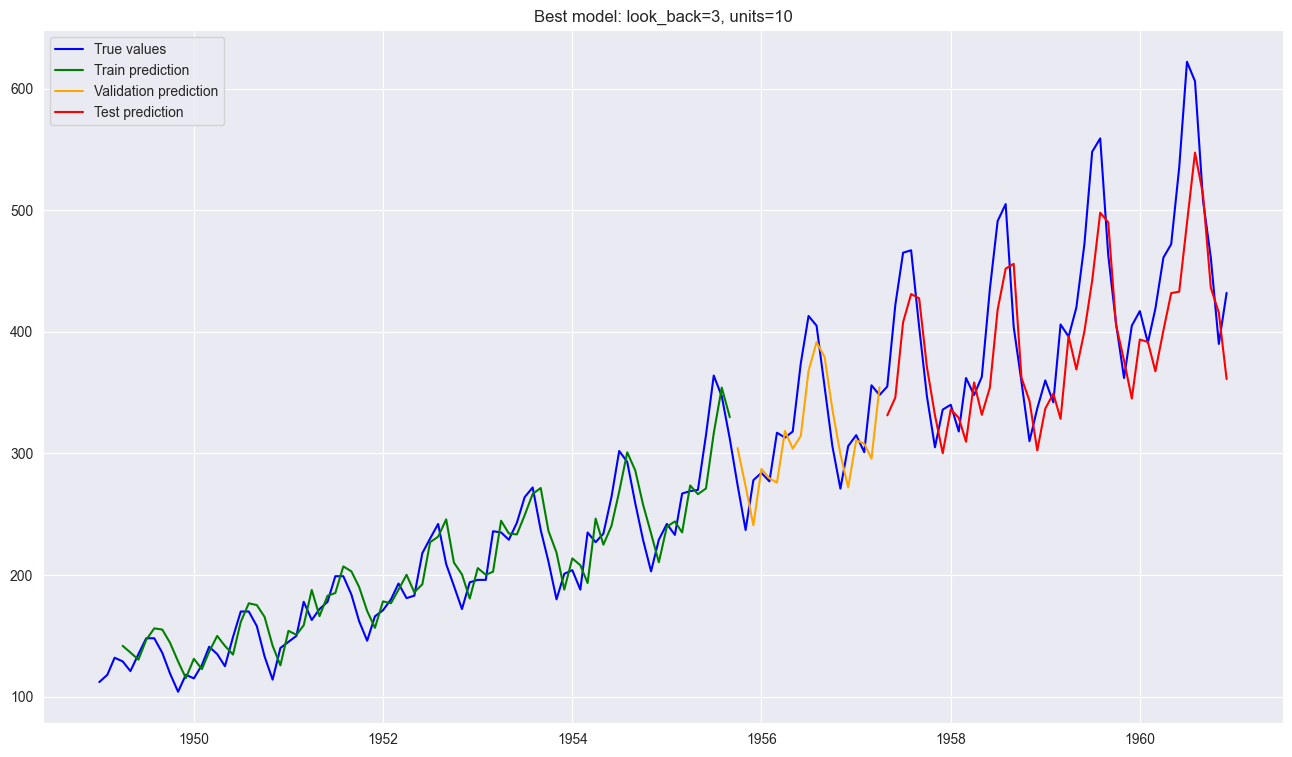

In [25]:
X_train, y_train, X_val, y_val, X_test, y_test = best_data
look_back = best_config[0]

train_pred = best_scaler.inverse_transform(best_model.predict(X_train))
val_pred   = best_scaler.inverse_transform(best_model.predict(X_val))
test_pred  = best_scaler.inverse_transform(best_model.predict(X_test))

train_idx = dataset.index[look_back:look_back+len(train_pred)]
val_idx   = dataset.index[look_back+len(train_pred):look_back+len(train_pred)+len(val_pred)]
test_idx  = dataset.index[train_size:train_size+len(test_pred)]

plt.figure(figsize=(16,9))
plt.plot(dataset['Passengers'], label='True values', color='blue')
plt.plot(train_idx, train_pred.flatten(), label='Train prediction', color='green')
plt.plot(val_idx, val_pred.flatten(), label='Validation prediction', color='orange')
plt.plot(test_idx, test_pred.flatten(), label='Test prediction', color='red')
plt.legend()
plt.title(f'Best model: look_back={best_config[0]}, units={best_config[1]}')
plt.show()